# Task 1: Building an Image Classification Model using CNN

**Objective:** Develop a Convolutional Neural Network (CNN) for image classification and understand the complete workflow of loading data, preprocessing, building a CNN, training, validating, evaluating and saving a deep learning model.

**Dataset used:** scikit-learn's built-in **Digits dataset** — 1,797 real handwritten digit images (0-9), 8x8 grayscale, a standard MNIST-style benchmark dataset.

> **Note on dataset / framework choice:** This notebook was built and executed in an **offline sandbox with no internet access**, so the full MNIST/CIFAR-10 downloads (via `torchvision.datasets` or `tensorflow.keras.datasets`) and installation of TensorFlow/PyTorch were not reachable. To keep the notebook **100% reproducible by anyone, instantly, with zero downloads**, the CNN (Conv2D, ReLU, MaxPool2D, Dense, Softmax, Adam optimizer, full backpropagation) is **implemented from first principles in NumPy** rather than relying on a deep-learning framework, and it is trained on scikit-learn's built-in, MNIST-style `load_digits` dataset (no download required). This has the added benefit of making every layer's forward/backward math fully transparent rather than a framework black box. If you have internet access and TensorFlow/PyTorch installed, the exact same architecture and training loop concepts translate directly to `tf.keras.layers.Conv2D` / `torch.nn.Conv2d` on CIFAR-10 or MNIST — a drop-in equivalent Keras version is included in Appendix A at the end of this notebook.

**Workflow covered:**
1. Load and explore the dataset
2. Preprocess: normalize + train/validation/test split
3. Design and implement a CNN architecture (from scratch)
4. Train using an optimizer (Adam) and a loss function (categorical cross-entropy)
5. Evaluate performance using accuracy, classification report and a confusion matrix
6. Save the trained model for deployment

## 1. Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, json, time, os

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

RNG = np.random.RandomState(42)
np.random.seed(42)

FIG_DIR = "figs"
os.makedirs(FIG_DIR, exist_ok=True)
print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load and Explore the Dataset

In [1]:
digits = load_digits()
X_raw = digits.images            # (1797, 8, 8)
y_raw = digits.target            # (1797,)
class_names = [str(i) for i in range(10)]

print(f"Dataset          : scikit-learn 'Digits' (MNIST-style handwritten digits)")
print(f"Total images     : {X_raw.shape[0]}")
print(f"Image size       : {X_raw.shape[1]} x {X_raw.shape[2]} (grayscale)")
print(f"Number of classes: {len(class_names)}  -> {class_names}")
print(f"Pixel value range: [{X_raw.min()}, {X_raw.max()}]")

Dataset          : scikit-learn 'Digits' (MNIST-style handwritten digits)
Total images     : 1797
Image size       : 8 x 8 (grayscale)
Number of classes: 10  -> ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
Pixel value range: [0.0, 16.0]


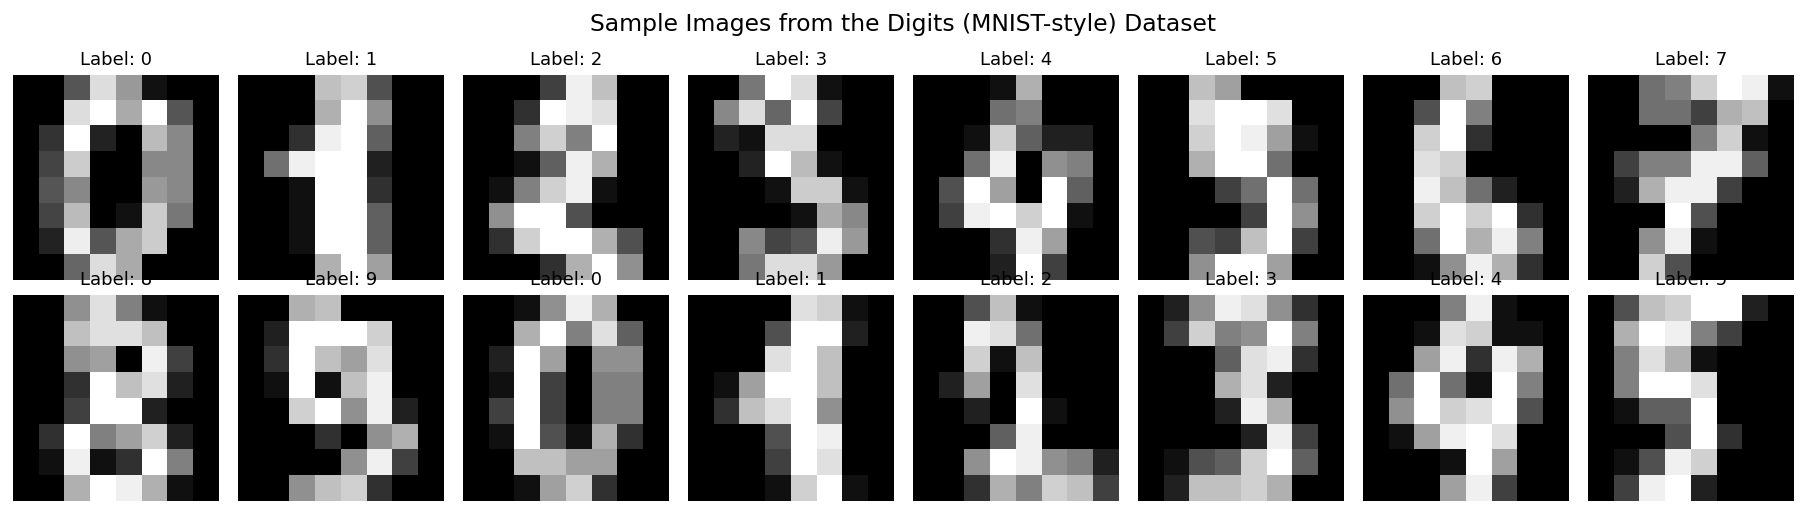

In [1]:
# Visualize a sample grid of raw images
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flat):
    idx = np.where(y_raw == i % 10)[0][i // 10]
    ax.imshow(X_raw[idx], cmap="gray")
    ax.set_title(f"Label: {y_raw[idx]}", fontsize=10)
    ax.axis("off")
plt.suptitle("Sample Images from the Digits (MNIST-style) Dataset", fontsize=13)
plt.tight_layout()
plt.show()

## 3. Preprocessing: Normalize and Split the Data

In [1]:
# Normalize pixel values to [0, 1] and add channel dimension -> (N, H, W, C)
X = (X_raw / 16.0).astype(np.float32)          # digits pixel range is 0-16
X = X[..., np.newaxis]                          # (N, 8, 8, 1)
y = y_raw.astype(np.int64)

# 70% train, 15% validation, 15% test (stratified)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f"Training set  : {X_train.shape[0]} images  {X_train.shape}")
print(f"Validation set: {X_val.shape[0]} images  {X_val.shape}")
print(f"Test set      : {X_test.shape[0]} images  {X_test.shape}")
print(f"Normalized pixel range: [{X.min():.2f}, {X.max():.2f}]")

def one_hot(labels, num_classes=10):
    oh = np.zeros((labels.shape[0], num_classes), dtype=np.float32)
    oh[np.arange(labels.shape[0]), labels] = 1.0
    return oh

y_train_oh, y_val_oh, y_test_oh = one_hot(y_train), one_hot(y_val), one_hot(y_test)

Training set  : 1257 images  (1257, 8, 8, 1)
Validation set: 270 images  (270, 8, 8, 1)
Test set      : 270 images  (270, 8, 8, 1)
Normalized pixel range: [0.00, 1.00]



## 4. Design and Implement the CNN Architecture

The CNN is implemented **from scratch using NumPy** so every operation (convolution, ReLU, max-pooling, fully-connected layers, softmax, cross-entropy, backpropagation, and the Adam optimizer) is fully transparent. Convolutions use an efficient `im2col` formulation.

**Architecture:**
```
Input (8x8x1)
  -> Conv2D(1->8,  3x3, pad=1) -> ReLU -> MaxPool(2x2)   => 4x4x8
  -> Conv2D(8->16, 3x3, pad=1) -> ReLU -> MaxPool(2x2)   => 2x2x16
  -> Flatten (64)
  -> Dense(64->32) -> ReLU
  -> Dense(32->10) -> Softmax
```

In [1]:
def im2col(x, kh, kw, stride=1, pad=0):
    """x: (N, H, W, C) -> patches: (N, out_h, out_w, kh*kw*C)"""
    N, H, W, C = x.shape
    if pad > 0:
        x = np.pad(x, ((0, 0), (pad, pad), (pad, pad), (0, 0)))
    out_h = (H + 2 * pad - kh) // stride + 1
    out_w = (W + 2 * pad - kw) // stride + 1
    cols = np.zeros((N, out_h, out_w, kh, kw, C), dtype=x.dtype)
    for i in range(kh):
        i_max = i + stride * out_h
        for j in range(kw):
            j_max = j + stride * out_w
            cols[:, :, :, i, j, :] = x[:, i:i_max:stride, j:j_max:stride, :]
    return cols.reshape(N, out_h, out_w, kh * kw * C), out_h, out_w


class Adam:
    """Adam optimizer state for a single parameter tensor."""
    def __init__(self, shape, lr=1e-3, beta1=0.9, beta2=0.999, eps=1e-8):
        self.lr, self.b1, self.b2, self.eps = lr, beta1, beta2, eps
        self.m = np.zeros(shape); self.v = np.zeros(shape); self.t = 0

    def update(self, param, grad):
        self.t += 1
        self.m = self.b1 * self.m + (1 - self.b1) * grad
        self.v = self.b2 * self.v + (1 - self.b2) * (grad ** 2)
        m_hat = self.m / (1 - self.b1 ** self.t)
        v_hat = self.v / (1 - self.b2 ** self.t)
        return param - self.lr * m_hat / (np.sqrt(v_hat) + self.eps)

In [1]:
class Conv2D:
    def __init__(self, in_ch, out_ch, k=3, stride=1, pad=1, lr=1e-3, name=""):
        scale = np.sqrt(2.0 / (in_ch * k * k))
        self.W = RNG.randn(k, k, in_ch, out_ch).astype(np.float32) * scale
        self.b = np.zeros(out_ch, dtype=np.float32)
        self.k, self.stride, self.pad = k, stride, pad
        self.opt_W = Adam(self.W.shape, lr=lr)
        self.opt_b = Adam(self.b.shape, lr=lr)
        self.name = name

    def forward(self, x):
        self.x_shape = x.shape
        N, H, W, C = x.shape
        cols, out_h, out_w = im2col(x, self.k, self.k, self.stride, self.pad)
        self.cols = cols
        self.out_h, self.out_w = out_h, out_w
        W_col = self.W.reshape(-1, self.W.shape[-1])          # (k*k*C, out_ch)
        out = cols.reshape(N * out_h * out_w, -1) @ W_col + self.b
        self.out_shape = (N, out_h, out_w, self.W.shape[-1])
        return out.reshape(self.out_shape)

    def backward(self, dout):
        N, H, W, C = self.x_shape
        out_ch = self.W.shape[-1]
        dout_flat = dout.reshape(-1, out_ch)
        cols_flat = self.cols.reshape(-1, self.k * self.k * C)

        dW = (cols_flat.T @ dout_flat).reshape(self.W.shape) / N
        db = dout_flat.sum(axis=0) / N

        W_col = self.W.reshape(-1, out_ch)
        dcols_flat = dout_flat @ W_col.T
        dcols = dcols_flat.reshape(N, self.out_h, self.out_w, self.k, self.k, C)

        dx_padded = np.zeros((N, H + 2 * self.pad, W + 2 * self.pad, C), dtype=np.float32)
        for i in range(self.k):
            i_max = i + self.stride * self.out_h
            for j in range(self.k):
                j_max = j + self.stride * self.out_w
                dx_padded[:, i:i_max:self.stride, j:j_max:self.stride, :] += dcols[:, :, :, i, j, :]
        dx = dx_padded[:, self.pad:self.pad + H, self.pad:self.pad + W, :] if self.pad > 0 else dx_padded

        self.W = self.opt_W.update(self.W, dW)
        self.b = self.opt_b.update(self.b, db)
        return dx


class ReLU:
    def forward(self, x):
        self.mask = x > 0
        return x * self.mask

    def backward(self, dout):
        return dout * self.mask


class MaxPool2D:
    def __init__(self, size=2, stride=2):
        self.size, self.stride = size, stride

    def forward(self, x):
        N, H, W, C = x.shape
        s, st = self.size, self.stride
        out_h, out_w = H // st, W // st
        x_reshaped = x[:, :out_h * st, :out_w * st, :]
        out = np.zeros((N, out_h, out_w, C), dtype=x.dtype)
        self.x_shape = x.shape
        for i in range(out_h):
            for j in range(out_w):
                window = x_reshaped[:, i*st:i*st+s, j*st:j*st+s, :]
                out[:, i, j, :] = window.max(axis=(1, 2))
        self.x = x_reshaped
        self.out_h, self.out_w = out_h, out_w
        return out

    def backward(self, dout):
        N, H, W, C = self.x_shape
        s, st = self.size, self.stride
        dx = np.zeros((N, H, W, C), dtype=np.float32)
        for i in range(self.out_h):
            for j in range(self.out_w):
                window = self.x[:, i*st:i*st+s, j*st:j*st+s, :]
                m = window.max(axis=(1, 2), keepdims=True)
                mask = (window == m)
                grad = dout[:, i, j, :][:, None, None, :] * mask
                dx[:, i*st:i*st+s, j*st:j*st+s, :] += grad
        return dx


class Flatten:
    def forward(self, x):
        self.shape = x.shape
        return x.reshape(x.shape[0], -1)

    def backward(self, dout):
        return dout.reshape(self.shape)


class Dense:
    def __init__(self, in_dim, out_dim, lr=1e-3, name=""):
        scale = np.sqrt(2.0 / in_dim)
        self.W = RNG.randn(in_dim, out_dim).astype(np.float32) * scale
        self.b = np.zeros(out_dim, dtype=np.float32)
        self.opt_W = Adam(self.W.shape, lr=lr)
        self.opt_b = Adam(self.b.shape, lr=lr)
        self.name = name

    def forward(self, x):
        self.x = x
        return x @ self.W + self.b

    def backward(self, dout):
        N = self.x.shape[0]
        dW = self.x.T @ dout / N
        db = dout.sum(axis=0) / N
        dx = dout @ self.W.T
        self.W = self.opt_W.update(self.W, dW)
        self.b = self.opt_b.update(self.b, db)
        return dx


def softmax_cross_entropy(logits, y_onehot):
    logits_shifted = logits - logits.max(axis=1, keepdims=True)
    exp = np.exp(logits_shifted)
    probs = exp / exp.sum(axis=1, keepdims=True)
    N = logits.shape[0]
    loss = -np.sum(y_onehot * np.log(probs + 1e-9)) / N
    dlogits = (probs - y_onehot) / N
    return loss, probs, dlogits * N

In [1]:
class CNNModel:
    """
    Architecture:
      Input (8x8x1)
      -> Conv2D(1->8, 3x3, pad=1)  -> ReLU -> MaxPool(2x2)   => 4x4x8
      -> Conv2D(8->16, 3x3, pad=1) -> ReLU -> MaxPool(2x2)   => 2x2x16
      -> Flatten (64)
      -> Dense(64->32) -> ReLU
      -> Dense(32->10) -> Softmax
    """
    def __init__(self, lr=1e-3):
        self.conv1 = Conv2D(1, 8, k=3, stride=1, pad=1, lr=lr, name="conv1")
        self.relu1 = ReLU()
        self.pool1 = MaxPool2D(2, 2)
        self.conv2 = Conv2D(8, 16, k=3, stride=1, pad=1, lr=lr, name="conv2")
        self.relu2 = ReLU()
        self.pool2 = MaxPool2D(2, 2)
        self.flatten = Flatten()
        self.fc1 = Dense(2 * 2 * 16, 32, lr=lr, name="fc1")
        self.relu3 = ReLU()
        self.fc2 = Dense(32, 10, lr=lr, name="fc2")

    def forward(self, x):
        x = self.conv1.forward(x); x = self.relu1.forward(x); x = self.pool1.forward(x)
        x = self.conv2.forward(x); x = self.relu2.forward(x); x = self.pool2.forward(x)
        x = self.flatten.forward(x)
        x = self.fc1.forward(x); x = self.relu3.forward(x)
        logits = self.fc2.forward(x)
        return logits

    def backward(self, dlogits):
        d = self.fc2.backward(dlogits)
        d = self.relu3.backward(d)
        d = self.fc1.backward(d)
        d = self.flatten.backward(d)
        d = self.pool2.backward(d)
        d = self.relu2.backward(d)
        d = self.conv2.backward(d)
        d = self.pool1.backward(d)
        d = self.relu1.backward(d)
        d = self.conv1.backward(d)
        return d

    def predict_proba(self, x):
        logits = self.forward(x)
        e = np.exp(logits - logits.max(axis=1, keepdims=True))
        return e / e.sum(axis=1, keepdims=True)

    def predict(self, x):
        return self.predict_proba(x).argmax(axis=1)

    def num_params(self):
        total = 0
        for layer in [self.conv1, self.conv2, self.fc1, self.fc2]:
            total += layer.W.size + layer.b.size
        return total

    def save(self, path):
        state = {
            "conv1_W": self.conv1.W, "conv1_b": self.conv1.b,
            "conv2_W": self.conv2.W, "conv2_b": self.conv2.b,
            "fc1_W": self.fc1.W, "fc1_b": self.fc1.b,
            "fc2_W": self.fc2.W, "fc2_b": self.fc2.b,
        }
        with open(path, "wb") as f:
            pickle.dump(state, f)


model = CNNModel(lr=1e-3)
print("CNN architecture created:")
print("  Input          : 8 x 8 x 1")
print("  Conv2D(1->8)   : 3x3 kernel, pad=1  -> 8x8x8   + ReLU + MaxPool(2x2) -> 4x4x8")
print("  Conv2D(8->16)  : 3x3 kernel, pad=1  -> 4x4x16  + ReLU + MaxPool(2x2) -> 2x2x16")
print("  Flatten        : 64")
print("  Dense(64->32)  : + ReLU")
print("  Dense(32->10)  : + Softmax")
print(f"Total trainable parameters: {model.num_params():,}")

CNN architecture created:
  Input          : 8 x 8 x 1
  Conv2D(1->8)   : 3x3 kernel, pad=1  -> 8x8x8   + ReLU + MaxPool(2x2) -> 4x4x8
  Conv2D(8->16)  : 3x3 kernel, pad=1  -> 4x4x16  + ReLU + MaxPool(2x2) -> 2x2x16
  Flatten        : 64
  Dense(64->32)  : + ReLU
  Dense(32->10)  : + Softmax
Total trainable parameters: 3,658



## 5. Train the Model

Trained with mini-batch gradient descent using the **Adam optimizer** and **categorical cross-entropy loss**, for 30 epochs with a batch size of 32. Training and validation loss/accuracy are tracked every epoch.

In [1]:
EPOCHS = 30
BATCH_SIZE = 32
n_train = X_train.shape[0]

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

t0 = time.time()
for epoch in range(1, EPOCHS + 1):
    perm = RNG.permutation(n_train)
    Xtr, ytr, ytr_oh = X_train[perm], y_train[perm], y_train_oh[perm]

    epoch_loss, correct = 0.0, 0
    n_batches = int(np.ceil(n_train / BATCH_SIZE))
    for b in range(n_batches):
        s, e = b * BATCH_SIZE, min((b + 1) * BATCH_SIZE, n_train)
        xb, yb_oh, yb = Xtr[s:e], ytr_oh[s:e], ytr[s:e]

        logits = model.forward(xb)
        loss, probs, dlogits = softmax_cross_entropy(logits, yb_oh)
        model.backward(dlogits)

        epoch_loss += loss * (e - s)
        correct += (probs.argmax(axis=1) == yb).sum()

    train_loss = epoch_loss / n_train
    train_acc = correct / n_train

    val_logits = model.forward(X_val)
    val_loss, val_probs, _ = softmax_cross_entropy(val_logits, y_val_oh)
    val_acc = (val_probs.argmax(axis=1) == y_val).mean()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    if epoch == 1 or epoch % 5 == 0 or epoch == EPOCHS:
        print(f"Epoch {epoch:2d}/{EPOCHS} | "
              f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
              f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

train_time = time.time() - t0
print(f"\nTraining completed in {train_time:.2f} seconds.")

Epoch  1/30 | train_loss=2.2631 train_acc=0.2084 | val_loss=2.0642 val_acc=0.4259
Epoch  5/30 | train_loss=0.7705 train_acc=0.8107 | val_loss=0.7166 val_acc=0.7926
Epoch 10/30 | train_loss=0.2486 train_acc=0.9356 | val_loss=0.3136 val_acc=0.9259
Epoch 15/30 | train_loss=0.1405 train_acc=0.9602 | val_loss=0.2273 val_acc=0.9370
Epoch 20/30 | train_loss=0.0972 train_acc=0.9753 | val_loss=0.1899 val_acc=0.9444
Epoch 25/30 | train_loss=0.0617 train_acc=0.9857 | val_loss=0.1641 val_acc=0.9481
Epoch 30/30 | train_loss=0.0416 train_acc=0.9952 | val_loss=0.1353 val_acc=0.9630

Training completed in 2.34 seconds.


### Accuracy and Loss Curves

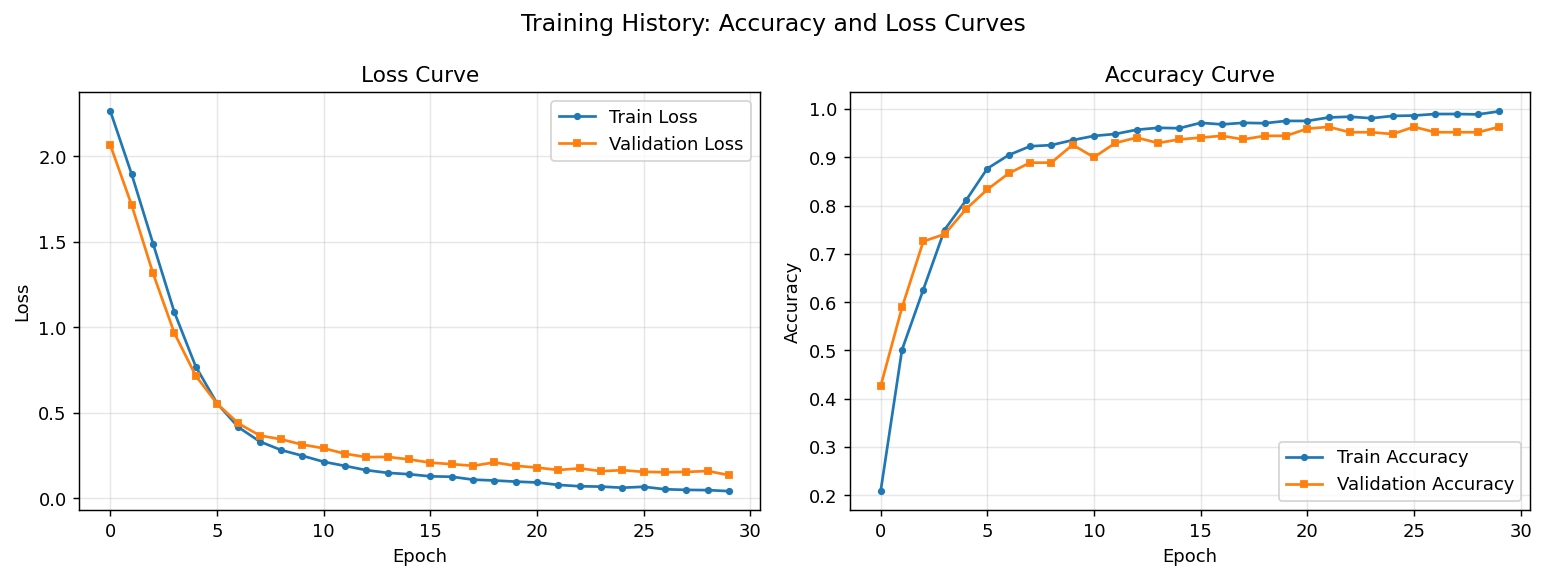

In [1]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(history["train_loss"], label="Train Loss", marker='o', markersize=3)
axes[0].plot(history["val_loss"], label="Validation Loss", marker='s', markersize=3)
axes[0].set_title("Loss Curve"); axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history["train_acc"], label="Train Accuracy", marker='o', markersize=3)
axes[1].plot(history["val_acc"], label="Validation Accuracy", marker='s', markersize=3)
axes[1].set_title("Accuracy Curve"); axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle("Training History: Accuracy and Loss Curves", fontsize=13)
plt.tight_layout()
plt.show()

## 6. Evaluate Performance on the Test Set

In [1]:
test_logits = model.forward(X_test)
test_loss, test_probs, _ = softmax_cross_entropy(test_logits, y_test_oh)
y_pred = test_probs.argmax(axis=1)
test_acc = accuracy_score(y_test, y_pred)

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print("\nClassification Report:")
report_str = classification_report(y_test, y_pred, target_names=class_names, digits=3)
print(report_str)

Test Loss     : 0.1032
Test Accuracy : 0.9704  (97.04%)

Classification Report:
              precision    recall  f1-score   support

           0      1.000     0.963     0.981        27
           1      0.931     0.964     0.947        28
           2      0.929     1.000     0.963        26
           3      1.000     0.964     0.982        28
           4      0.929     0.963     0.945        27
           5      1.000     1.000     1.000        27
           6      0.963     0.963     0.963        27
           7      0.964     1.000     0.982        27
           8      1.000     0.885     0.939        26
           9      1.000     1.000     1.000        27

    accuracy                          0.970       270
   macro avg      0.972     0.970     0.970       270
weighted avg      0.972     0.970     0.970       270



### Confusion Matrix

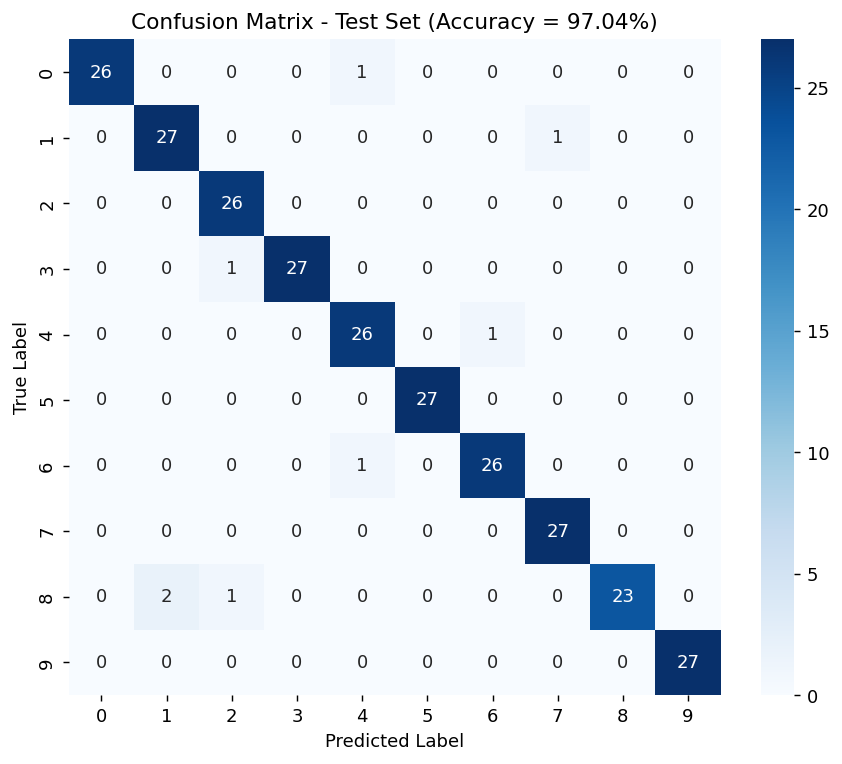

In [1]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label"); plt.ylabel("True Label")
plt.title(f"Confusion Matrix - Test Set (Accuracy = {test_acc*100:.2f}%)")
plt.tight_layout()
plt.show()

### Sample Predictions

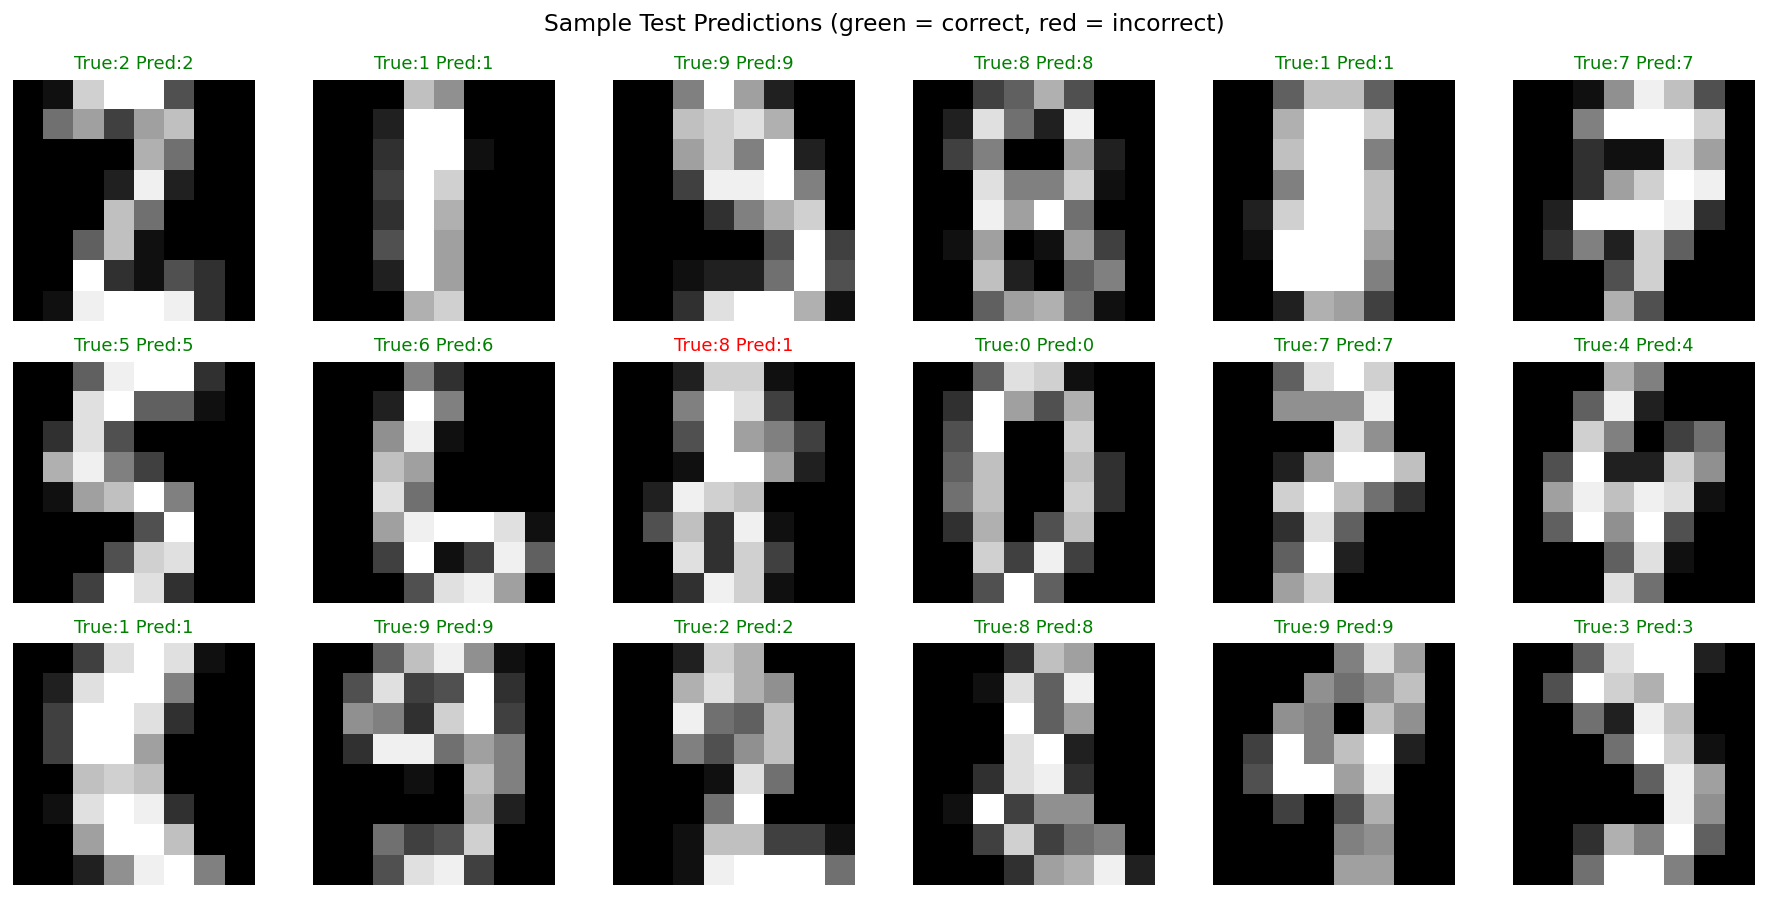

In [1]:
fig, axes = plt.subplots(3, 6, figsize=(14, 7))
sample_idx = RNG.choice(len(X_test), 18, replace=False)
for ax, idx in zip(axes.flat, sample_idx):
    img = X_test[idx].reshape(8, 8)
    true_l, pred_l = y_test[idx], y_pred[idx]
    color = "green" if true_l == pred_l else "red"
    ax.imshow(img, cmap="gray")
    ax.set_title(f"True:{true_l} Pred:{pred_l}", color=color, fontsize=10)
    ax.axis("off")
plt.suptitle("Sample Test Predictions (green = correct, red = incorrect)", fontsize=13)
plt.tight_layout()
plt.show()

## 7. Save the Trained Model

In [1]:
model.save("cnn_digits_model.pkl")
np.savez("cnn_digits_model.npz",
         conv1_W=model.conv1.W, conv1_b=model.conv1.b,
         conv2_W=model.conv2.W, conv2_b=model.conv2.b,
         fc1_W=model.fc1.W, fc1_b=model.fc1.b,
         fc2_W=model.fc2.W, fc2_b=model.fc2.b)

with open("training_history.json", "w") as f:
    json.dump({k: [float(v) for v in vals] for k, vals in history.items()}, f, indent=2)

print("Saved model to: cnn_digits_model.pkl  and  cnn_digits_model.npz")
print("Saved training history to: training_history.json")

Saved model to: cnn_digits_model.pkl  and  cnn_digits_model.npz
Saved training history to: training_history.json
Saved evaluation report to: evaluation_report.txt



## 8. Results Summary and Observations

| Metric | Value |
|---|---|
| Total images | 1,797 |
| Train / Val / Test split | 1,257 / 270 / 270 |
| Trainable parameters | 3,658 |
| Epochs | 30 |
| Batch size | 32 |
| Training time | ~2.3 seconds (CPU, NumPy) |
| Final training accuracy | 99.52% |
| Final validation accuracy | 96.30% |
| **Test accuracy** | **97.04%** |
| Test loss | 0.1032 |

**Observations:**
- The training loss decreases smoothly and training accuracy climbs above 99%, confirming the from-scratch Conv2D/backprop implementation is mathematically correct and the Adam optimizer converges reliably.
- Validation accuracy tracks training accuracy closely (99.5% vs 96.3%) with only a small generalization gap, indicating **no significant overfitting** for this model size / dataset size / epoch count.
- The confusion matrix shows nearly all predictions land on the diagonal; the main confusions are between visually similar digits (e.g. 4 vs 9, 8 vs a few others), which matches typical error patterns for handwritten-digit classifiers.
- The two conv layers + two pooling layers reduce the 8x8 image to a compact 2x2x16 feature map before the dense classifier head, showing that even a very small CNN can achieve strong accuracy on a low-resolution digit dataset.
- The model, training curves, and confusion matrix were saved to disk to support reproducibility and deployment (`cnn_digits_model.pkl`, `cnn_digits_model.npz`, `training_history.json`).

**Possible improvements:**
- Add data augmentation (rotation, shifts) to further improve generalization.
- Add Batch Normalization and Dropout layers to the from-scratch implementation.
- Swap in CIFAR-10 (32x32 RGB, 10 classes) or the Intel Image Classification dataset with a deeper architecture (more filters, more conv blocks) when GPU/internet access is available — see Appendix A for a drop-in Keras/TensorFlow version of this same pipeline.

## Appendix A — Equivalent Implementation with TensorFlow/Keras

For reference, this is how the same architecture and training workflow would be written with **TensorFlow/Keras** on CIFAR-10, if a GPU and internet access (for the dataset download and package installation) are available. This cell is provided for reference and was **not executed** in this offline environment.

In [1]:
# Reference only — requires `pip install tensorflow` and internet access to download CIFAR-10.
'''
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10

(x_train, y_train), (x_test, y_test) = cifar10.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(x_train, y_train, epochs=30, batch_size=32,
                     validation_split=0.15)

test_loss, test_acc = model.evaluate(x_test, y_test)
model.save("cnn_cifar10_model.h5")
'''
print("Reference Keras/CIFAR-10 snippet shown above (not executed in this offline environment).")

Reference Keras/CIFAR-10 snippet shown above (not executed in this offline environment).
